In [34]:
import numpy as np 
import pandas as pd
import itertools
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [35]:
# Load the dataset
DATA_PATH = '../VinhLong_data.csv'
data = pd.read_csv(DATA_PATH)
data = data[data['Nhiệt độ'] <= 60]

In [36]:
data.shape

(84589, 7)

In [37]:
data.dtypes

Ngày         object
Giờ          object
Nhiệt độ    float64
Độ ẩm        object
Khí áp       object
T.độ gió     object
H. gió       object
dtype: object

In [38]:
data['Ngày'] = pd.to_datetime(data['Ngày'], format='%d/%m/%Y')
data['Giờ'] = pd.to_datetime(data['Giờ'], format='%H:%M').dt.time
data['Datetime'] = pd.to_datetime(data['Ngày'].astype(str) + ' ' + data['Giờ'].astype(str))
data.set_index('Datetime', inplace=True)
data.drop(['Ngày', 'Giờ'], axis=1, inplace=True)
data.head()

,Nhiệt độ,Độ ẩm,Khí áp,T.độ gió,H. gió
Datetime,,,,,
2014-01-01 01:00:00,22.2,89,1013.7,1.3,225
2014-01-01 02:00:00,21.8,90,1012.9,1,270
2014-01-01 03:00:00,22.8,80,1012.5,3.1,320
2014-01-01 04:00:00,22.7,80,1012.5,1.2,235
2014-01-01 05:00:00,22.0,84,1012.5,3.7,319


In [39]:
data.replace(['-', ''], np.nan, inplace=True)
data.dropna(inplace=True)
data = data.apply(pd.to_numeric, errors='ignore')
data.tail()

,Nhiệt độ,Độ ẩm,Khí áp,T.độ gió,H. gió
Datetime,,,,,
2024-01-15 19:00:00,28.3,65,1011.8,2.2,154
2024-01-15 20:00:00,27.4,70,1012.1,2.1,152
2024-01-15 21:00:00,27.0,72,1012.5,0.2,149
2024-01-15 22:00:00,26.5,75,1012.2,1.3,153
2024-02-21 07:00:00,24.4,97,1012.6,1.4,142


In [40]:
data.dtypes

Nhiệt độ    float64
Độ ẩm         int64
Khí áp      float64
T.độ gió    float64
H. gió        int64
dtype: object

In [41]:
print(data.isna().sum())

Nhiệt độ    0
Độ ẩm       0
Khí áp      0
T.độ gió    0
H. gió      0
dtype: int64


In [42]:
print("Start date:", data.index.min())
print("End date:", data.index.max())

Start date: 2014-01-01 01:00:00
End date: 2024-02-21 07:00:00


In [43]:
print(isinstance(data, pd.DataFrame))

True


In [44]:
daily_data = data.resample('D').mean()
daily_data.replace(['-', ''], np.nan, inplace=True)
daily_data.dropna(inplace=True)
daily_data = daily_data.apply(pd.to_numeric, errors='ignore')
daily_data.tail()

,Nhiệt độ,Độ ẩm,Khí áp,T.độ gió,H. gió
Datetime,,,,,
2023-12-31,29.95,71.0,1010.55,2.00,205.0
2024-01-06,27.30,89.0,1014.20,1.70,132.0
2024-01-10,31.05,56.5,1009.35,2.35,171.0
2024-01-15,27.30,70.5,1012.15,1.45,152.0
2024-02-21,24.40,97.0,1012.60,1.40,142.0


In [ ]:
# daily_data.reset_index(drop=True, inplace=True)
# daily_data = daily_data.asfreq('D')

In [45]:
daily_data.head()

,Nhiệt độ,Độ ẩm,Khí áp,T.độ gió,H. gió
Datetime,,,,,
2014-01-01,24.852174,78.739130,1012.978261,1.947826,266.826087
2014-01-02,25.143478,84.347826,1012.326087,1.469565,165.347826
2014-01-03,25.713043,84.869565,1012.086957,1.200000,174.565217
2014-01-04,26.243478,86.000000,1011.547826,1.552174,158.086957
2014-01-05,25.975000,83.416667,1010.875000,1.645833,136.708333


In [46]:
daily_data.shape

(3568, 5)

In [47]:
print(daily_data.isna().sum())

Nhiệt độ    0
Độ ẩm       0
Khí áp      0
T.độ gió    0
H. gió      0
dtype: int64


Splitting Data for Training and Testing Purpose

In [48]:
data_length = len(daily_data)

train_idx = int(data_length * 0.80)
test_idx = int(data_length * 0.20)

# Split the daily_data into train and test
train = daily_data[:train_idx]
test = daily_data[train_idx:]

# Check the shape of the datasets to verify the splits
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Train Shape: (2854, 5)
Test Shape: (714, 5)


In [49]:
from statsmodels.tsa.stattools import adfuller

In [50]:
def check_adfuller(data):
    result=adfuller(data, autolag='AIC')
    print("1. ADF statistics:{}".format(result[0]))
    print("2. p-value:{}".format(result[1]))
    print("3. Num of lags:{}".format(result[2]))
    print("4. No of observation:{}".format(result[3]))
    print("5. Critical Values:")
    for key,value in result[4].items():
        print("Critical({}):{}".format(key,value))

In [51]:
check_adfuller(daily_data['Nhiệt độ'])

1. ADF statistics:-7.171614081059903
2. p-value:2.7950052800754473e-10
3. Num of lags:14
4. No of observation:3553
5. Critical Values:
Critical(1%):-3.4321918324656684
Critical(5%):-2.862353817855558
Critical(10%):-2.5672032087248784


The data is stationary
ARIMA = Auto Regressive Moving Average Model
for checking the order of Auto Regressive Model -> use PACF
for checking the order of Moving Average Model -> use ACF

In [58]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.api as sm    
from statsmodels.tsa.arima_process import ArmaProcess

In [55]:
alpha_1 = 0.5

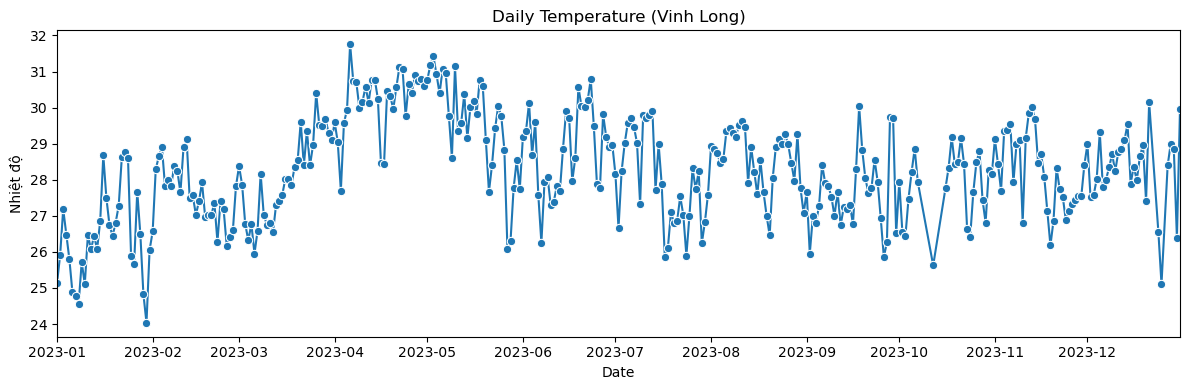

In [ ]:
series = daily_data['Nhiệt độ'].loc['2023'].copy()
series = series.sort_index().asfreq('D') 

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 4))
sns.lineplot(x=series.index, y=series.values, marker='o', ax=ax)
ax.set_xlim([series.index.min(), series.index.max()])
ax.set_title('Daily Temperature (Vinh Long)')
ax.set_xlabel('Date')
ax.set_ylabel('Nhiệt độ')
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

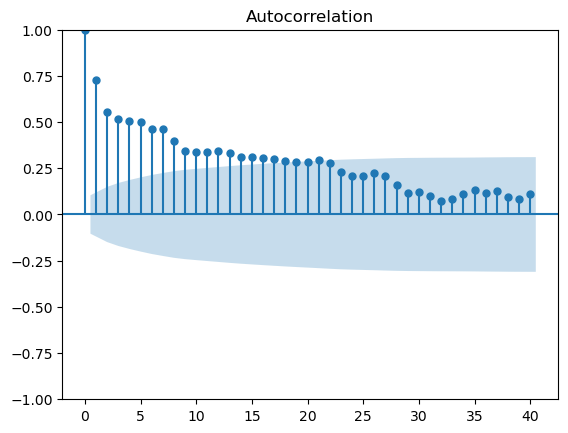

<Figure size 1000x400 with 0 Axes>

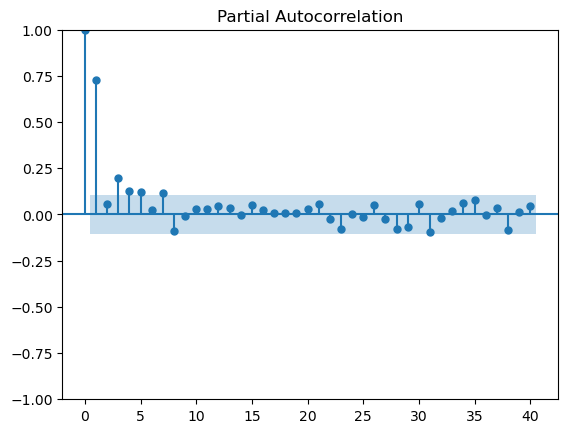

In [70]:
plt.figure(figsize=(10,4))
plot_acf(series.dropna(), lags=40)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(series.dropna(), lags=40, method='ywm')
plt.show()

Time series data is stationary

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

In [ ]:
# Fit the ARIMA model
model = ARIMA(train['Nhiệt độ'], order=(1, 0, 1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:               Nhiệt độ   No. Observations:                 2854
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -3884.635
Date:                Fri, 12 Sep 2025   AIC                           7777.269
Time:                        14:56:26   BIC                           7801.095
Sample:                             0   HQIC                          7785.861
                               - 2854                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9825      0.112    249.114      0.000      27.762      28.203
ar.L1          0.8925      0.010     88.092      0.000       0.873       0.912
ma.L1         -0.3178      0.020    -16.275      0.0

/Users/ellieryus/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ellieryus/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ellieryus/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Users/ellieryus/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


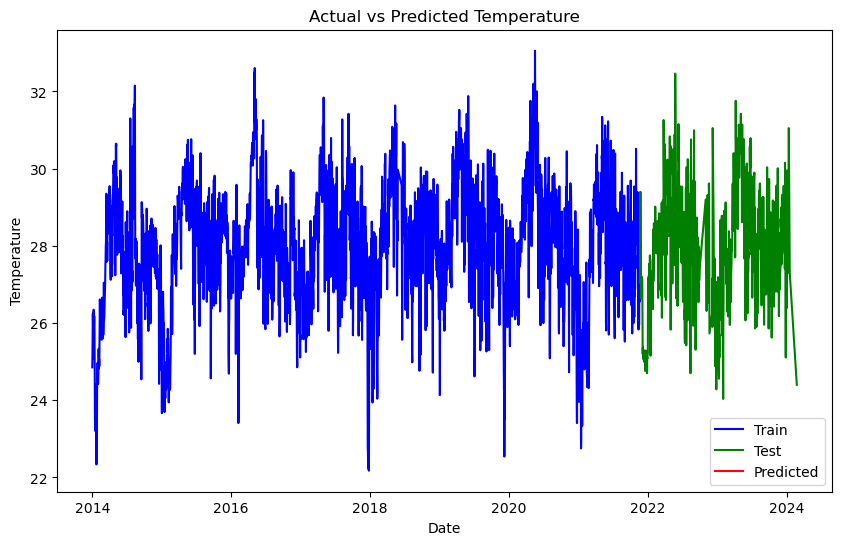

In [21]:
# Forecast the test set
forecast = results.forecast(steps=len(test))

# Convert forecast to a Series and align with the test index
prediction_results = pd.Series(forecast, index=test.index, name="Predicted")

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))

# Plot the actual data
plt.plot(train.index, train['Nhiệt độ'], label='Train', color='blue')
plt.plot(test.index, test['Nhiệt độ'], label='Test', color='green')

# Plot the predicted data
plt.plot(prediction_results.index, prediction_results, label='Predicted', color='red')

# Customize the plot
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature")
plt.legend(loc="best")
plt.show()


In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(test['Nhiệt độ'], prediction_results)
rmse = np.sqrt(mse)
print(f'The RMSE of the ARIMA model is: {rmse:.3f}')


The RMSE of the ARIMA model is: 1.492


In [24]:
results = model.fit(disp=0)

TypeError: ARIMA.fit() got an unexpected keyword argument 'disp'